In [1]:
import sys, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import glob
import pandas as pd
import itertools
import numpy as np
from pathlib import Path

In [2]:
from tqdm.notebook import tqdm

tqdm.pandas()

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [6]:
DATA_PATH=f"{cfg.DATA_PATH}crimebb/"
CSV_PATH = f"{DATA_PATH}/{cfg.YEAR}/csv/"
CSV_PROCESSED = f"{CSV_PATH}/websites/"
HF_PROCESSED = f"{DATA_PATH}/{cfg.YEAR}/csv/topics/{cfg.TOPIC_SEARCH}/"
verifyDir(HF_PROCESSED)

In [7]:
%%time
hf_reader = pd.read_csv(f"{CSV_PROCESSED}hackforums.csv", sep=cfg.CSV_SEP, low_memory=False, iterator=True)
            
hf_df = pd.DataFrame()

len_readed=cfg.CHUNK_SIZE
while len_readed>=cfg.CHUNK_SIZE:
    current_df = hf_reader.get_chunk(cfg.CHUNK_SIZE).copy()
    len_readed = current_df.shape[0]
    current_df.drop_duplicates(inplace=True)
    
    #current_df = current_df[["site_name", "board_title", "thread_id", "thread_title", "content", "post_data_creation"]].copy().drop_duplicates()
    current_df = current_df[~current_df["content"].isna()].copy()
    current_df.drop_duplicates(inplace=True)
    
    current_df["board_title"] = current_df["board_title"].astype(str)
    current_df["thread_title"] = current_df["thread_title"].astype(str)
    current_df["content"] = current_df["content"].astype(str)
    
    hf_df = pd.concat([hf_df, current_df], ignore_index=True)
    
    del current_df
    gc.collect()

CPU times: user 2min 45s, sys: 1min 3s, total: 3min 49s
Wall time: 4min 50s


In [8]:
hf_df[hf_df["board_title"].isna()]

,post_id,site_id,board_id,thread_id,user_id,site_name,board_title,thread_title,username,content,user_reputation,post_data_creation


In [9]:
hf_df[hf_df["thread_title"].isna()]

,post_id,site_id,board_id,thread_id,user_id,site_name,board_title,thread_title,username,content,user_reputation,post_data_creation
247470,4278902,0,127,446169,110782,hackforums.net,Referrals,NaN,0xE9,well this is the source and it all put togethe...,-32,2010-05-28 18:43:00-03
247471,4278895,0,127,446169,156732,hackforums.net,Referrals,NaN,Aeonhack Archivist,Hey man...can you upload to $harecash. I am f...,104,2010-05-28 18:42:00-03
247472,4278819,0,127,446169,243401,hackforums.net,Referrals,NaN,ipwnuuaal5,the surveys arent free. you have to use your c...,0,2010-05-28 18:36:00-03
405181,40830328,0,107,4300494,2319577,hackforums.net,Premium Sellers Section,NaN,Hydrotime,This post is closed term service NULLL Sorry.,9,2014-06-22 11:51:00-03
407188,41019464,0,107,4318690,2319577,hackforums.net,Premium Sellers Section,NaN,Hydrotime,This post is closed term service NULLL Sorry.,9,2014-07-02 11:13:00-03
...,...,...,...,...,...,...,...,...,...,...,...,...
41066317,58272959,0,25,5941650,2682887,hackforums.net,The Lounge,NaN,Mr. Robot,Welcome to hackforums Bama,712,2019-02-16 13:52:00-02
41066318,58272671,0,25,5941650,3396409,hackforums.net,The Lounge,NaN,PerfectStorm,Welcome to hackforums.\n\nDon't forget to read...,1503,2019-02-16 11:57:00-02
41066319,58272651,0,25,5941650,4145712,hackforums.net,The Lounge,NaN,bamasean,New to here I love yo learn anything and speci...,0,2019-02-16 11:48:00-02
41148940,58467037,0,107,5960025,4153126,hackforums.net,Premium Sellers Section,NaN,Steam,"Give them to charity.\n\nYour ""roommate"" is br...",109,2019-04-13 20:56:00-03


In [10]:
hf_df[hf_df["content"].isna()]

,post_id,site_id,board_id,thread_id,user_id,site_name,board_title,thread_title,username,content,user_reputation,post_data_creation


In [11]:
hf_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41570288 entries, 0 to 41570287
Data columns (total 12 columns):
 #   Column              Dtype
---  ------              -----
 0   post_id             int64
 1   site_id             int64
 2   board_id            int64
 3   thread_id           int64
 4   user_id             int64
 5   site_name           str  
 6   board_title         str  
 7   thread_title        str  
 8   username            str  
 9   content             str  
 10  user_reputation     int64
 11  post_data_creation  str  
dtypes: int64(6), str(6)
memory usage: 15.6 GB


In [12]:
hf_df["post_time"] = hf_df["post_data_creation"].apply(lambda x: x.split(" ")[0])
hf_df.head(4)

,post_id,site_id,board_id,thread_id,user_id,site_name,board_title,thread_title,username,content,user_reputation,post_data_creation,post_time
0,57270050,0,25,5854579,3924584,hackforums.net,The Lounge,Let's talk about how awesome things are!,Katie2203,***CITING***[https://hackforums.net/showthread...,77,2018-06-26 22:39:00-03,2018-06-26
1,57270046,0,25,5854579,1200358,hackforums.net,The Lounge,Let's talk about how awesome things are!,Gσđfαtђα,***CITING***[https://hackforums.net/showthread...,498,2018-06-26 22:38:00-03,2018-06-26
2,45594351,0,89,4766670,2503489,hackforums.net,News and Happenings,Edward Snowden on TED,fanufveufenu,***CITING***[https://hackforums.net/showthread...,-52,2015-04-07 10:02:00-03,2015-04-07
3,57270043,0,25,5854579,3396409,hackforums.net,The Lounge,Let's talk about how awesome things are!,PerfectStorm,Someone smoked for the first time? thehe,365,2018-06-26 22:37:00-03,2018-06-26


 #### Temporal data

CPU times: user 3.5 s, sys: 4.73 s, total: 8.23 s
Wall time: 8.31 s


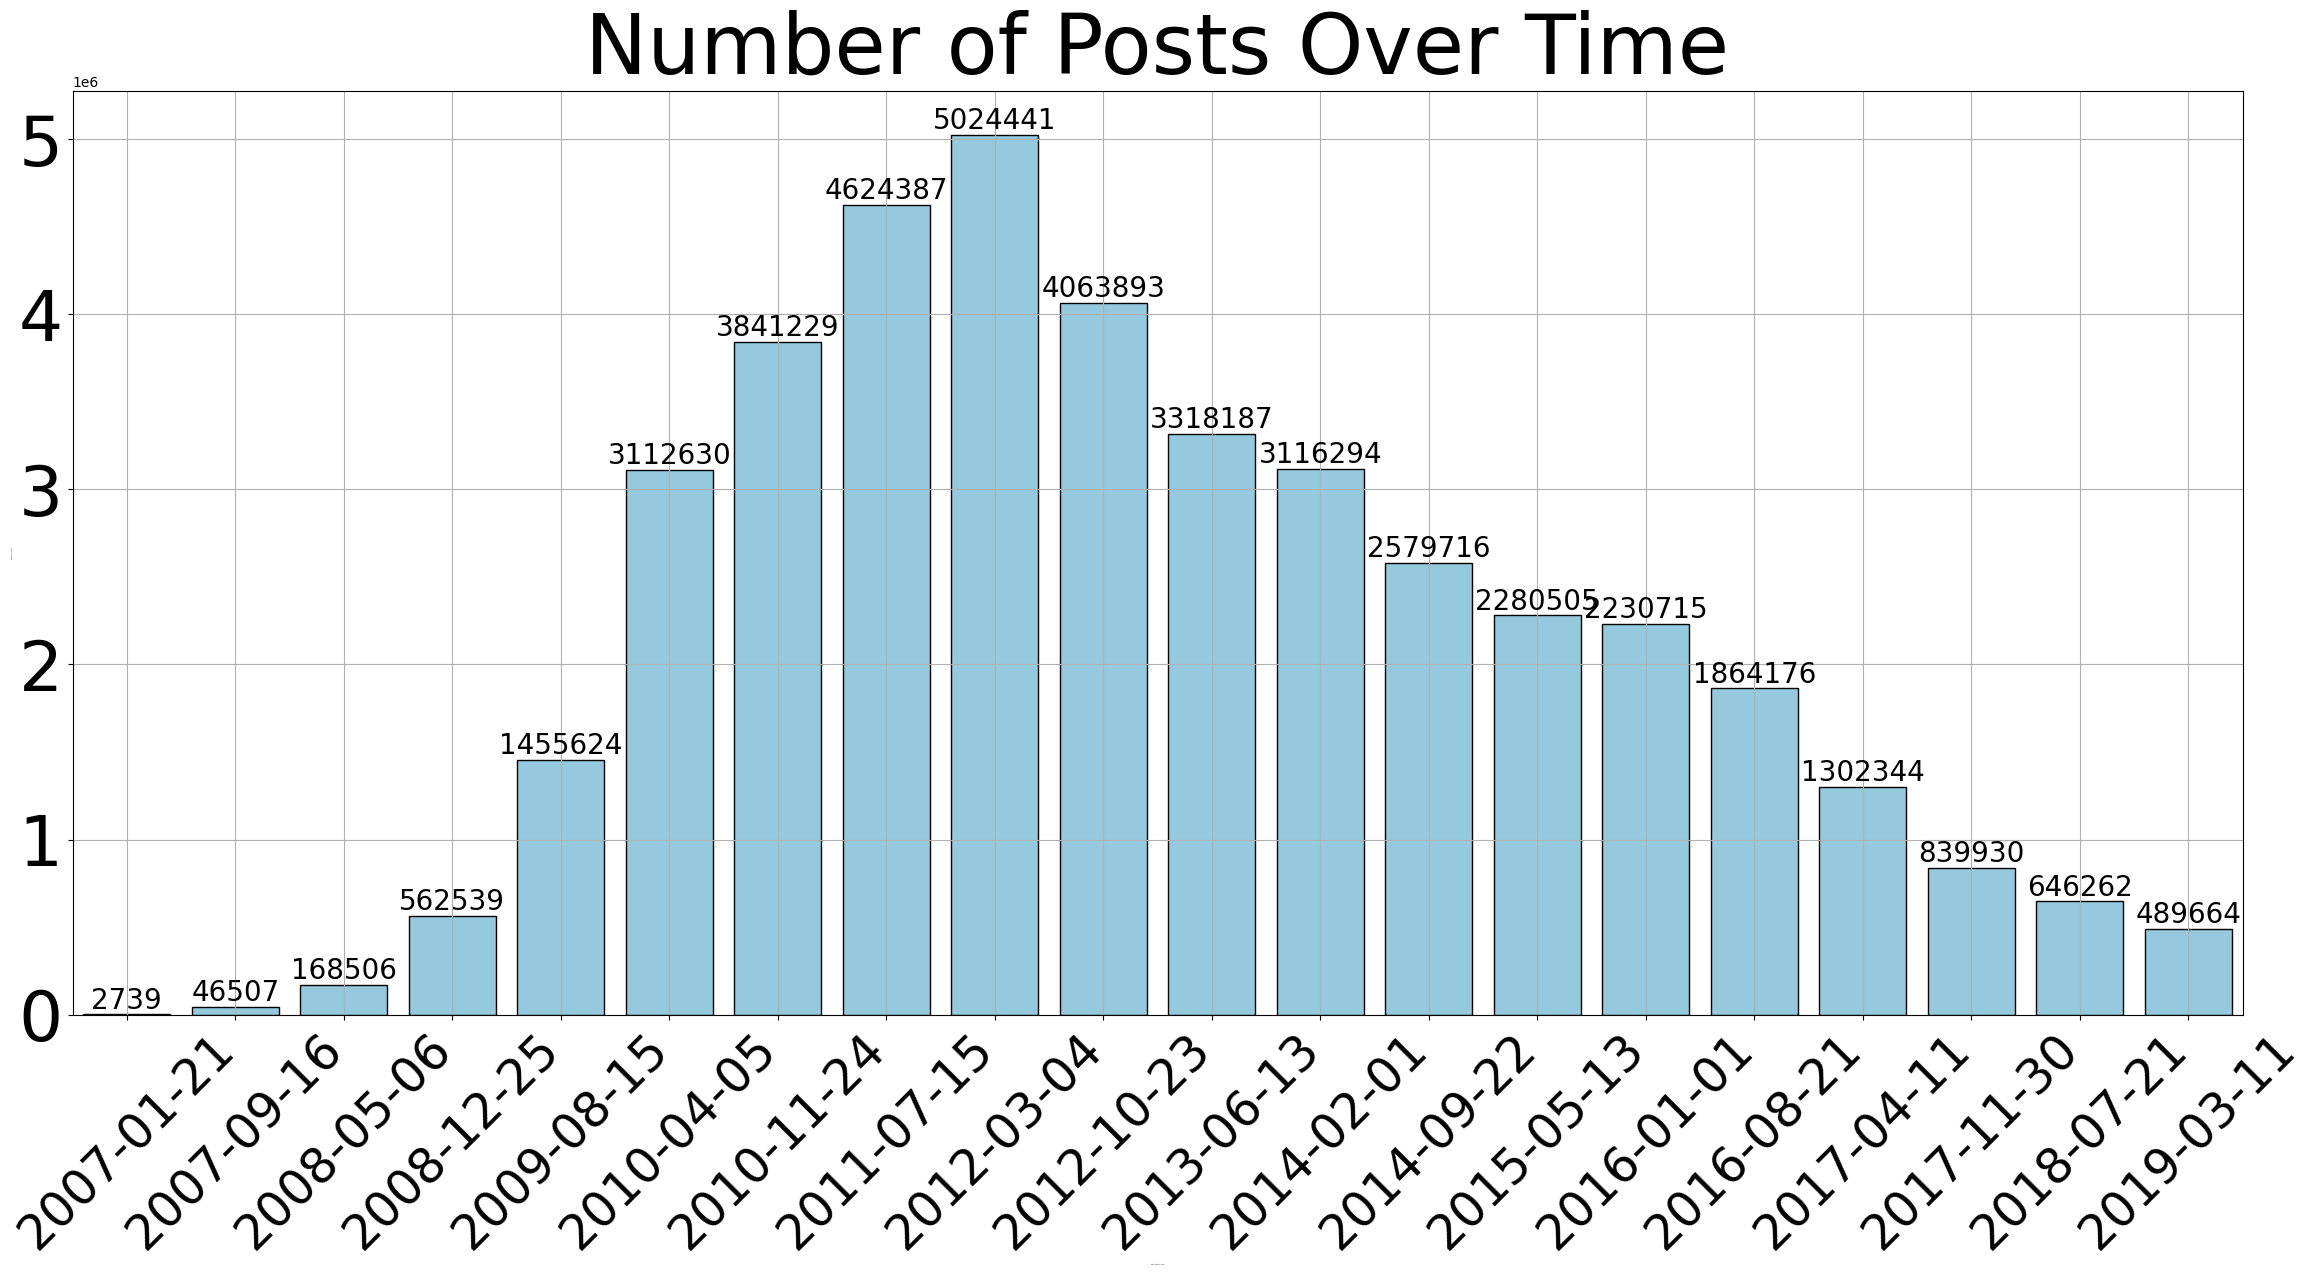

In [13]:
%%time
time_df = pd.pivot_table(hf_df,
              index=["post_time"],
              values=["content"],
              aggfunc={
                  "content":len
              }).reset_index()
time_df['post_time'] = pd.to_datetime(time_df['post_time'])
min_date = time_df['post_time'].min()
max_date = time_df['post_time'].max()

bins = pd.date_range(start=min_date, end=max_date, freq='ME')
# Digitize the post times to get bin indices
time_df['bin'] = pd.cut(time_df['post_time'], bins=20)
# Aggregate the mentions by bin
mentions_per_bin = time_df.groupby('bin')['content'].sum().reset_index()

# Prepare data for plotting
mentions_per_bin['bin'] = mentions_per_bin['bin'].apply(lambda x: x.left.date())

_, ax = plt.subplots(figsize=(28,12), nrows=1, ncols=1, sharex=False, sharey=False)

sns_fig = sns.barplot(data=mentions_per_bin, 
                      x=mentions_per_bin.columns[0], 
                      y=mentions_per_bin.columns[1], 
                      ax=ax,
                      color="skyblue",
                      edgecolor='black')

sns_fig.set_title('Number of Posts Over Time', fontsize=60)
sns_fig.set_ylabel('Number of posts', fontsize=0)
sns_fig.set_xlabel('Post creation time', fontsize=0)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=35)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=20,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

### Obtaining CVEs

In [14]:
%%time
hf_df["total_content"] = hf_df["board_title"].str.lower() + cfg.KEYWORD_SEP +hf_df["thread_title"].str.lower() + cfg.KEYWORD_SEP + hf_df["content"].str.lower()

CPU times: user 9.58 s, sys: 5.8 s, total: 15.4 s
Wall time: 15.4 s


In [15]:
%%time
if cfg.TOPIC_SEARCH:
    hf_df["cve_codes_list"] = hf_df["total_content"].apply(lambda x: re.findall(r'(cve[-]?[0-9]*[-]?[0-9]*)', str(x).lower(), flags=re.IGNORECASE) )
else:
    hf_df["cve_codes_list"] = hf_df["total_content"].apply(lambda x: re.findall(r'(cve-[0-9]{4}-[0-9]{4,})', str(x).lower(), flags=re.IGNORECASE) )

hf_df["cve_codes_len"] = hf_df["cve_codes_list"].apply(lambda x: len(x) )
hf_df["cve_unique_list"] = hf_df["cve_codes_list"].apply(lambda x: list(set(itertools.chain(x))))
hf_df["cve_unique_len"] = hf_df["cve_unique_list"].apply(lambda x: len(x) )
hf_df.sort_values(by="cve_unique_len", ascending=False, inplace=True)

CPU times: user 2min, sys: 23.5 s, total: 2min 24s
Wall time: 2min 24s


In [16]:
hf_posts_df = hf_df[hf_df["cve_unique_len"]>0].copy()
hf_posts_df

,post_id,site_id,board_id,thread_id,user_id,site_name,board_title,thread_title,username,content,user_reputation,post_data_creation,post_time,total_content,cve_codes_list,cve_codes_len,cve_unique_list,cve_unique_len
38474008,40824400,0,4,4299925,1471209,hackforums.net,Beginner Hacking,+Pentesting: Anyone have a list of vulnerable ...,UkVenoM,***CITING***[https://hackforums.net/showthread...,38,2014-06-22 14:18:00-03,2014-06-22,beginner hacking FAMVEERFAMVEERFAMVEER +pentes...,"[cve-2014-0323, cve-2014-0317, cve-2014-0315, ...",62,"[cve-2013-3136, cve-2010-3147, cve-2011-0096, ...",59
40490223,39537241,0,13,4176757,2068191,hackforums.net,Computer Protection and Security Alerts,[WARNING] Update your Java installation - j8u5...,Null Byte,***IMG***[https://i.imgur.com/kxTfXwL.png]***I...,-97,2014-04-16 20:44:00-03,2014-04-16,computer protection and security alerts FAMVEE...,"[cve-, cve-2013-6629, cve-2013-6954, cve-2014-...",38,"[cve-2014-0432, cve-2014-1876, cve-2014-2413, ...",38
20430752,36180394,0,110,3851963,503768,hackforums.net,"White Hat Malware, Virus, and Rat Removal Help",Possible infection?,apt-get money,***LINK***https://hackforums.net/showthread.ph...,119,2013-11-07 21:12:00-02,2013-11-07,"white hat malware, virus, and rat removal help...","[cve-2008-5499, cve-2008-5499, cve-2010-0480, ...",77,"[cve-2012-4681, cve-2010-0822, cve-2006-0295, ...",36
38197484,53395549,0,92,5490019,3368411,hackforums.net,"Botnets, IRC Bots, and Zombies",Terror Exploit Kit [DUMP],Andrew Carnegie,Yes i am the original owner of terror exploit ...,-5,2016-12-10 11:05:00-02,2016-12-10,"botnets, irc bots, and zombies FAMVEERFAMVEERF...","[cve-2014-6332, cve, cve, cve, cve, cve, cve, ...",53,"[cve-2015-0802, cve-2016-7865, cve-2014-2483, ...",30
14833489,46809508,0,231,4083645,2689701,hackforums.net,Pentesting and Forensics,[Tutorial] ~ Writing TCP Bind Shell in Linux A...,xorl,***CITING***[https://hackforums.net/showthread...,10,2015-06-30 09:32:00-03,2015-06-30,pentesting and forensics FAMVEERFAMVEERFAMVEER...,"[cve-2015-3113, cve-2015-2717, cve-2015-1360, ...",21,"[cve-2015-3070, cve-2015-2717, cve-2015-4002, ...",21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4225147,32619643,0,43,3464927,1792652,hackforums.net,Website and Forum Hacking,[Tutorial] Exploiting the RCE vulnerability in...,мαѕтєямιη∂,"Awesome bro, whats the background behind your ...",52,2013-05-14 05:38:00-03,2013-05-14,website and forum hacking FAMVEERFAMVEERFAMVEE...,[cve-2012-1823],1,[cve-2012-1823],1
4225145,32658955,0,43,3464927,278777,hackforums.net,Website and Forum Hacking,[Tutorial] Exploiting the RCE vulnerability in...,engrαze,"Oh what, I completely missed this thread someh...",72,2013-05-16 03:11:00-03,2013-05-16,website and forum hacking FAMVEERFAMVEERFAMVEE...,[cve-2012-1823],1,[cve-2012-1823],1
4225144,32659896,0,43,3464927,531250,hackforums.net,Website and Forum Hacking,[Tutorial] Exploiting the RCE vulnerability in...,Th3PonyWizard,Great tutorial.\n***CITING***[https://hackforu...,31,2013-05-16 04:58:00-03,2013-05-16,website and forum hacking FAMVEERFAMVEERFAMVEE...,[cve-2012-1823],1,[cve-2012-1823],1
4225146,32658489,0,43,3464927,42381,hackforums.net,Website and Forum Hacking,[Tutorial] Exploiting the RCE vulnerability in...,Phizo,***CITING***[https://hackforums.net/showthread...,138,2013-05-16 02:29:00-03,2013-05-16,website and forum hacking FAMVEERFAMVEERFAMVEE...,[cve-2012-1823],1,[cve-2012-1823],1


In [17]:
unique_cve_codes = list(set(itertools.chain(*hf_posts_df["cve_unique_list"].values)))
len(unique_cve_codes)#, unique_cve_codes

1174

In [18]:
hf_posts_df.drop(columns=["total_content", "cve_unique_len", "cve_codes_len"], inplace=True)

In [21]:
hf_posts_df.to_csv(f"{HF_PROCESSED}HackForums_CVE_Posts.csv", sep='\t', index=False)